In [2]:
import httpx
import time
import pandas as pd
import re
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import json
from pathlib import Path
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

/Users/mnatali/Projects/sentiment_analysis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
model_name = "yangheng/deberta-v3-base-absa-v1.1"

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name).to(device)
model.eval()


def aspect_sentiment(text, aspect, batch_size=16, max_length=512, stride=64):
    encoded = tokenizer(
        text,
        aspect,
        truncation=True,
        max_length=max_length,
        stride=stride,
        return_overflowing_tokens=True,
        padding=True,
        return_tensors="pt"
    )

    input_keys = ["input_ids", "attention_mask", "token_type_ids"]
    input_keys = [k for k in input_keys if k in encoded]

    all_probs = []

    with torch.inference_mode():
        n_chunks = encoded["input_ids"].shape[0]

        for start in range(0, n_chunks, batch_size):
            end = start + batch_size

            batch = {
                k: encoded[k][start:end].to(device)
                for k in input_keys
            }

            outputs = model(**batch)
            probs = F.softmax(outputs.logits, dim=-1)
            all_probs.append(probs)

    avg_probs = torch.cat(all_probs, dim=0).mean(dim=0).cpu()

    return {
        model.config.id2label[i]: float(avg_probs[i])
        for i in range(len(avg_probs))
    }

Using device: mps


/Users/mnatali/Projects/sentiment_analysis/.venv/lib/python3.13/site-packages/transformers/convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
Skipping import of cpp extensions due to incompatible torch version 2.9.1 for torchao version 0.16.0             Please see https://github.com/pytorch/ao/issues/2919 for more info
W0629 21:39:54.338000 34854 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [4]:
print(aspect_sentiment("I love the weather here! However, datacenters are a concern. The friendly neighbors hake up for it though!", "datacenters"))
sentiment = aspect_sentiment("I love the weather here! However, datacenters are a concern. The friendly neighbors hake up for it though!", "datacenters")

post_sentiments = []
post_sentiment_degrees = []

post_sentiments.append(max(sentiment, key=sentiment.get))
post_sentiment_degrees.append(max(sentiment.values()))

print(post_sentiments[0], post_sentiment_degrees[0])

{'Negative': 0.9916238188743591, 'Neutral': 0.007077292539179325, 'Positive': 0.0012989335227757692}
Negative 0.9916238188743591


In [5]:
file_path = Path("/Users/mnatali/Projects/sentiment_analysis/brightdata_across_social_media_analysis/brightdata_social_exports/x_datacenters_posts.json")

with file_path.open("r", encoding="utf-8") as f:
    x_posts = json.load(f)

In [6]:
'''
post_sentiments = []
post_sentiment_degrees = []

a = 0
for x_post in x_posts:
    a += 1
    sentiment = aspect_sentiment(x_post["description"], "datacenters")
    post_sentiments.append(max(sentiment, key=sentiment.get))
    post_sentiment_degrees.append(max(sentiment.values()))
    print("Posts scanned:", a, end="\r")
'''

'\npost_sentiments = []\npost_sentiment_degrees = []\n\na = 0\nfor x_post in x_posts:\n    a += 1\n    sentiment = aspect_sentiment(x_post["description"], "datacenters")\n    post_sentiments.append(max(sentiment, key=sentiment.get))\n    post_sentiment_degrees.append(max(sentiment.values()))\n    print("Posts scanned:", a, end="\r")\n'

In [7]:
'''
sentiments_backup = post_sentiments.copy()
sentiment_degrees_backup = post_sentiment_degrees.copy()

data = {
    "sentiments": post_sentiments,
    "sentiment_degrees": post_sentiment_degrees
}

with open("x_sentiments_backup.json", "w") as f:
    json.dump(data, f)
'''

'\nsentiments_backup = post_sentiments.copy()\nsentiment_degrees_backup = post_sentiment_degrees.copy()\n\ndata = {\n    "sentiments": post_sentiments,\n    "sentiment_degrees": post_sentiment_degrees\n}\n\nwith open("x_sentiments_backup.json", "w") as f:\n    json.dump(data, f)\n'

In [8]:
file_path = Path("/Users/mnatali/Projects/sentiment_analysis/brightdata_across_social_media_analysis/across_social_media_overall_sentiment_analysis/using_ABSA_CURRENT_TECHNIQUE/x_sentiments_backup.json")

with file_path.open("r", encoding="utf-8") as f:
    sentiments = json.load(f)

post_sentiments = sentiments["sentiments"]
post_sentiment_degrees = sentiments["sentiment_degrees"]

In [9]:
posts = pd.DataFrame(columns=["ids", "text", "date", "upvotes", "number of comments", "subreddit", "sentiment", "degree", "AWS", "Amazon", "Google", "Microsoft", "Azure", "Meta", "Oracle", "Equinix", "Digital Realty", "IBM", "Facebook", "Apple", "QTS", "Vantage", "CyrusOne", "CoreSite"])

post_ids = []
post_texts = []
post_dates = []
post_likes = []
post_num_replies = []
post_num_reposts = []
post_views = []

a = 0

for x_post in x_posts:
    a += 1

    post_ids.append(x_post["id"])
    post_texts.append(x_post["description"])
    post_dates.append(x_post["date_posted"])
    post_likes.append(x_post["likes"])
    post_num_replies.append(x_post["replies"])
    post_num_reposts.append(x_post["reposts"])
    if(x_post["views"] == None):
        post_views.append(0)
    else:
        post_views.append(x_post["views"])

    print("Posts scanned:", a, end="\r")


posts["ids"] = post_ids
posts["text"] = post_texts
posts["date"] = post_dates
posts["likes"] = post_likes
posts["number of replies"] = post_num_replies
posts["number of reposts"] = post_num_reposts
posts["number of views"] = post_views
posts["sentiment"] = post_sentiments
posts["degree"] = post_sentiment_degrees

In [10]:
posts = posts.astype({
    "ids": "string",
    "text": "string",
    "date": "string",
    "likes": "int64",
    "number of replies": "int64",
    "number of reposts": "int64",
    "number of views": "int64",
    "sentiment": "string",
    "degree": "float64",
    "AWS": "bool",
    "Amazon": "bool",
    "Google": "bool",
    "Microsoft": "bool",
    "Azure": "bool",
    "Meta": "bool",
    "Oracle": "bool",
    "Equinix": "bool",
    "Digital Realty": "bool",
    "IBM": "bool",
    "Facebook": "bool",
    "Apple": "bool",
    "QTS": "bool",
    "Vantage": "bool",
    "CyrusOne": "bool",
    "CoreSite": "bool"
})

In [11]:
company_terms = ["AWS","Amazon","Google","Microsoft","Azure","Meta","Oracle","Equinix","Digital Realty","IBM","Facebook","Apple","QTS","Vantage","CyrusOne","CoreSite"]

for c in company_terms:
    posts[c] = posts["text"].str.contains(rf'\b{re.escape(c)}\b', case=False, na=False)

posts_with_company = posts[posts[company_terms].any(axis=1)]
posts_with_company.head()

,ids,text,date,upvotes,number of comments,subreddit,sentiment,degree,AWS,Amazon,...,Facebook,Apple,QTS,Vantage,CyrusOne,CoreSite,likes,number of replies,number of reposts,number of views
3,1889456969771016378,Xcel rethinks land sale contracts after buyer ...,2025-02-11T23:30:20.000Z,NaN,NaN,NaN,Neutral,0.938838,False,True,...,False,False,False,False,False,False,6,0,1,5663
6,1881846447353557352,Microsoft agrees to let OpenAI use rival cloud...,2025-01-21T23:28:50.000Z,NaN,NaN,NaN,Neutral,0.978122,False,False,...,False,False,False,False,False,False,24,1,6,25987
9,1895082559479988528,AI’s Next Big Challenge: NVIDIA’s Compute Surg...,2025-02-27T12:04:25.000Z,NaN,NaN,NaN,Positive,0.511267,True,False,...,False,False,False,False,False,False,0,0,0,45
12,1970846856709353873,Oracle is set to spend hundreds of billions on...,2025-09-24T13:41:03.000Z,NaN,NaN,NaN,Neutral,0.919093,False,False,...,False,False,False,False,False,False,25,3,6,0
13,1970846633639240035,scoop: Oracle is looking to borrow $15 billion...,2025-09-24T13:35:07.000Z,NaN,NaN,NaN,Neutral,0.860371,False,False,...,False,False,False,False,False,False,11,1,3,0


In [12]:
def remove_links(text):
    url_pattern = re.compile(r'\[https?://\S+\]|\(https?://\S+\)|\[www\.\S+\]|\(www\.\S+\)')
    cleaned_text = url_pattern.sub('', text)
    return cleaned_text

posts["text"] = posts["text"].apply(remove_links)

In [13]:
len(posts)
posts.head()

,ids,text,date,upvotes,number of comments,subreddit,sentiment,degree,AWS,Amazon,...,Facebook,Apple,QTS,Vantage,CyrusOne,CoreSite,likes,number of replies,number of reposts,number of views
0,1658823223906037760,How Power Quality Intelligence Can Drive Data ...,2023-05-17T13:14:10.000Z,NaN,NaN,NaN,Neutral,0.793705,False,False,...,False,False,False,False,False,False,0,0,1,0
1,1762410996935561249,"ERT Member @Cheydema, CEO @orange, talks about...",2024-02-27T09:35:00.000Z,NaN,NaN,NaN,Positive,0.636997,False,False,...,False,False,False,False,False,False,0,0,0,117
2,1879208828257894583,Data center power demand will double over the ...,2025-01-14T16:47:53.000Z,NaN,NaN,NaN,Negative,0.630647,False,False,...,False,False,False,False,False,False,77,7,33,21271
3,1889456969771016378,Xcel rethinks land sale contracts after buyer ...,2025-02-11T23:30:20.000Z,NaN,NaN,NaN,Neutral,0.938838,False,True,...,False,False,False,False,False,False,6,0,1,5663
4,1894111303834255795,Just weeks after their father announced a majo...,2025-02-24T19:45:00.000Z,NaN,NaN,NaN,Neutral,0.947805,False,False,...,False,False,False,False,False,False,26,14,9,22041


In [14]:
print(posts.columns)

Index(['ids', 'text', 'date', 'upvotes', 'number of comments', 'subreddit',
       'sentiment', 'degree', 'AWS', 'Amazon', 'Google', 'Microsoft', 'Azure',
       'Meta', 'Oracle', 'Equinix', 'Digital Realty', 'IBM', 'Facebook',
       'Apple', 'QTS', 'Vantage', 'CyrusOne', 'CoreSite', 'likes',
       'number of replies', 'number of reposts', 'number of views'],
      dtype='object')


In [15]:
## total average sentiment calculation

pos = posts.loc[posts["sentiment"] == "Positive", "degree"].sum()
neg = posts.loc[posts["sentiment"] == "Negative", "degree"].sum()
total = posts["degree"].sum()
print("Average sentiment for all of x: ", (pos-neg)/total)

Average sentiment for all of x:  0.14127043115737298


In [16]:
pos = posts.loc[posts["sentiment"] == "Positive"]
neg = posts.loc[posts["sentiment"] == "Negative"]
neutral = posts.loc[posts["sentiment"] == "Neutral"]

print("Percent of posts that are neutral:", len(neutral)/len(posts))
print("Percent of posts that are negative:", len(neg)/len(posts))
print("Percent of posts that are positive:", len(pos)/len(posts))

really_pos = pos.loc[posts["degree"] > 0.90]
really_neg = neg.loc[posts["degree"] > 0.90]

if len(neg) != 0:
    print("Percent of negative posts that are really negative:", len(really_neg)/len(neg))
if len(pos) != 0:
    print("Percent of positive posts that are really positive:", len(really_pos)/len(pos))

Percent of posts that are neutral: 0.5732876712328767
Percent of posts that are negative: 0.13273972602739725
Percent of posts that are positive: 0.29397260273972603
Percent of negative posts that are really negative: 0.33746130030959753
Percent of positive posts that are really positive: 0.1798695246971109


In [17]:
def avg_sentiment_calculation(dataset):
    pos = dataset.loc[dataset["sentiment"] == "Positive", "degree"].sum()
    neg = dataset.loc[dataset["sentiment"] == "Negative", "degree"].sum()
    total = dataset["degree"].sum()
    if total != 0:
        return (pos-neg)/total
    else:
        return 0

posts['year'] = pd.to_datetime(posts['date']).dt.year

year_datasets = {year: posts[posts['year'] == year] for year in range(2010, 2027)}

for i in range(2010, 2027):
    print(f"Number of posts from {i}: ", len(year_datasets[i]))
    if(len(year_datasets[i]) != 0):
        print(f"Average sentiment for x posts from {i}: ", avg_sentiment_calculation(year_datasets[i]))

Number of posts from 2010:  0
Number of posts from 2011:  0
Number of posts from 2012:  2
Average sentiment for x posts from 2012:  0.5245510179220387
Number of posts from 2013:  0
Number of posts from 2014:  3
Average sentiment for x posts from 2014:  0.2297923219083383
Number of posts from 2015:  3
Average sentiment for x posts from 2015:  0.0
Number of posts from 2016:  5
Average sentiment for x posts from 2016:  0.18478966368945013
Number of posts from 2017:  7
Average sentiment for x posts from 2017:  0.3825880494490383
Number of posts from 2018:  9
Average sentiment for x posts from 2018:  -0.016317879473795004
Number of posts from 2019:  7
Average sentiment for x posts from 2019:  0.2687207017460976
Number of posts from 2020:  13
Average sentiment for x posts from 2020:  0.053852277564017684
Number of posts from 2021:  35
Average sentiment for x posts from 2021:  0.14636159495290588
Number of posts from 2022:  48
Average sentiment for x posts from 2022:  0.13008778976373742
Numb

In [18]:
print(avg_sentiment_calculation(year_datasets[2015]))


0.0


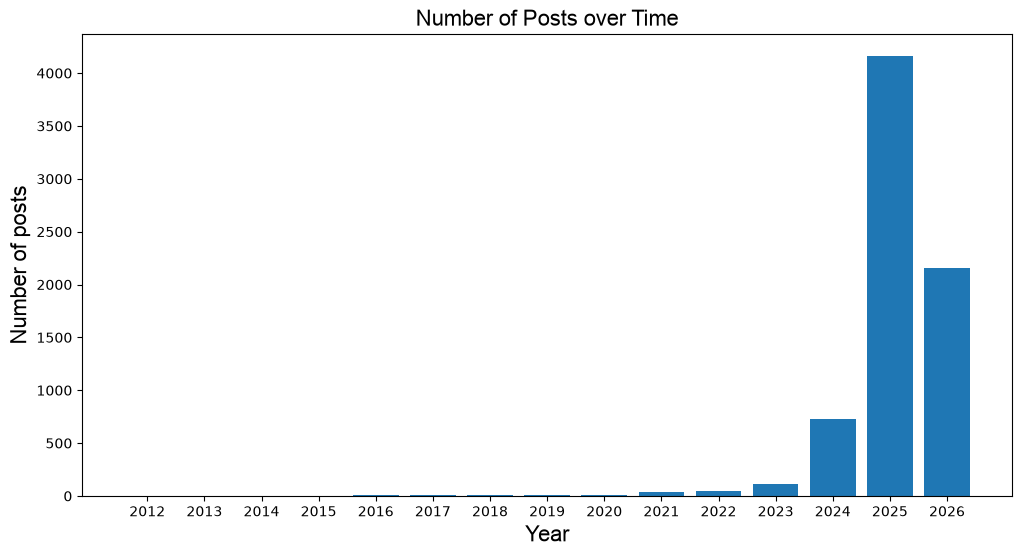

In [ ]:
categories = ["2012", "2013", "2014", "2015", "2016", "2017", "2018", "2019", "2020", "2021", "2022", "2023", "2024", "2025", "2026"]
counts = [len(year_datasets[2012]), len(year_datasets[2013]), len(year_datasets[2014]), len(year_datasets[2015]), len(year_datasets[2016]), len(year_datasets[2017]), len(year_datasets[2018]), len(year_datasets[2019]), len(year_datasets[2020]), len(year_datasets[2021]), len(year_datasets[2022]), len(year_datasets[2023]), len(year_datasets[2024]), len(year_datasets[2025]), len(year_datasets[2026])]

plt.figure(figsize=(12, 6))
plt.bar(categories, counts)

plt.title(
    "Number of Posts over Time",
    fontsize=16,
    fontname="Arial"
)

plt.xlabel(
    "Year",
    fontsize=16,
    fontname="Arial"
)

plt.ylabel(
    "Number of posts",
    fontsize=16,
    fontname="Arial"
)
plt.show()

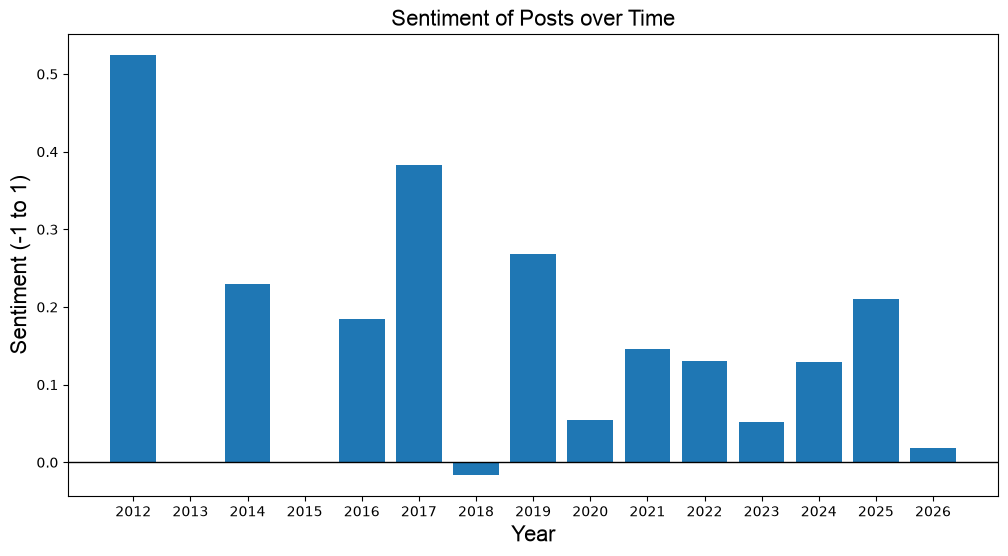

In [20]:
categories = ["2012", "2013", "2014", "2015", "2016", "2017", "2018", "2019", "2020", "2021", "2022", "2023", "2024", "2025", "2026"]
counts = [avg_sentiment_calculation(year_datasets[2012]), avg_sentiment_calculation(year_datasets[2013]), avg_sentiment_calculation(year_datasets[2014]), avg_sentiment_calculation(year_datasets[2015]), avg_sentiment_calculation(year_datasets[2016]), avg_sentiment_calculation(year_datasets[2017]), avg_sentiment_calculation(year_datasets[2018]), avg_sentiment_calculation(year_datasets[2019]), avg_sentiment_calculation(year_datasets[2020]), avg_sentiment_calculation(year_datasets[2021]), avg_sentiment_calculation(year_datasets[2022]), avg_sentiment_calculation(year_datasets[2023]), avg_sentiment_calculation(year_datasets[2024]), avg_sentiment_calculation(year_datasets[2025]), avg_sentiment_calculation(year_datasets[2026])]

plt.figure(figsize=(12, 6))
plt.bar(categories, counts)
plt.axhline(0, color="black", linewidth=1)

plt.title(
    "Sentiment of Posts over Time",
    fontsize=16,
    fontname="Arial"
)

plt.xlabel(
    "Year",
    fontsize=16,
    fontname="Arial"
)

plt.ylabel(
    "Sentiment (-1 to 1)",
    fontsize=16,
    fontname="Arial"
)
plt.show()

In [21]:
def sentiment_by_company(company1, company2=None):
    company_posts = posts[
        (posts[company1] == True) | (posts[company2] == True) if company2 else (posts[company1] == True)
    ]
    return avg_sentiment_calculation(company_posts)

print("Number of Amazon-related posts:", len(posts[posts["AWS"] == True]) + len(posts[posts["Amazon"] == True]))
print("Average sentiment of AWS-related posts:", sentiment_by_company("AWS", "Amazon"))
print("Number of Google-related posts:", len(posts[posts["Google"] == True]))
print("Average sentiment of Google-related posts:", sentiment_by_company("Google"))
print("Number of Microsoft-related posts:", len(posts[posts["Microsoft"] == True]) + len(posts[posts["Azure"] == True]))
print("Average sentiment of Microsoft-related posts:", sentiment_by_company("Microsoft", "Azure"))
print("Number of Meta-related posts:", len(posts[posts["Meta"] == True]) + len(posts[posts["Facebook"] == True]))
print("Average sentiment of Meta-related posts:", sentiment_by_company("Meta"))
print("Number of Oracle-related posts:", len(posts[posts["Oracle"] == True]))
print("Average sentiment of Oracle-related posts:", sentiment_by_company("Oracle"))
print("Number of Equinix-related posts:", len(posts[posts["Equinix"] == True]))
print("Average sentiment of Equinix-related posts:", sentiment_by_company("Equinix"))
print("Number of Digital Realty-related posts:", len(posts[posts["Digital Realty"] == True]))
print("Average sentiment of Digital Realty-related posts:", sentiment_by_company("Digital Realty"))
print("Number of IBM-related posts:", len(posts[posts["IBM"] == True]))
print("Average sentiment of IBM-related posts:", sentiment_by_company("IBM"))
print("Number of Apple-related posts:", len(posts[posts["Apple"] == True]))
print("Average sentiment of Apple-related posts:", sentiment_by_company("Apple"))
print("Number of QTS-related posts:", len(posts[posts["QTS"] == True]))
print("Average sentiment of QTS-related posts:", sentiment_by_company("QTS"))
print("Number of Vantage-related posts:", len(posts[posts["Vantage"] == True]))
print("Average sentiment of Vantage-related posts:", sentiment_by_company("Vantage"))
print("Number of CyrusOne-related posts:", len(posts[posts["CyrusOne"] == True]))
print("Average sentiment of CyrusOne-related posts:", sentiment_by_company("CyrusOne"))
print("Number of CoreSite-related posts:", len(posts[posts["CoreSite"] == True]))
print("Average sentiment of CoreSite-related posts:", sentiment_by_company("CoreSite"))

Number of Amazon-related posts: 461
Average sentiment of AWS-related posts: 0.24011399848337064
Number of Google-related posts: 536
Average sentiment of Google-related posts: 0.26553759484462514
Number of Microsoft-related posts: 555
Average sentiment of Microsoft-related posts: 0.2876373119282363
Number of Meta-related posts: 467
Average sentiment of Meta-related posts: 0.31049756427976066
Number of Oracle-related posts: 265
Average sentiment of Oracle-related posts: 0.3070375019275063
Number of Equinix-related posts: 26
Average sentiment of Equinix-related posts: 0.29784196349797476
Number of Digital Realty-related posts: 14
Average sentiment of Digital Realty-related posts: 0.6208873550553056
Number of IBM-related posts: 37
Average sentiment of IBM-related posts: 0.395273989577136
Number of Apple-related posts: 120
Average sentiment of Apple-related posts: 0.229431729858914
Number of QTS-related posts: 10
Average sentiment of QTS-related posts: 0.07333690370588236
Number of Vantage-

In [22]:
def analysis_of_viral_posts(min):
    viral_posts = posts.loc[posts["number of views"] >= min]
    non_viral_posts = posts.loc[posts["number of views"] < min]
    print("What's considered viral: posts with over", min, "views")
    print("Number of viral posts:", len(viral_posts))
    print("Average sentiment of viral posts:", avg_sentiment_calculation(viral_posts))
    print("Average sentiment of non-viral posts:", avg_sentiment_calculation(non_viral_posts))
    print("Amount percent of viral posts that are polar (degree) > 0.90: ", len(viral_posts.loc[viral_posts["degree"] > 0.90])/len(viral_posts))
    print("Percent of viral posts that are negative: ", (len(viral_posts.loc[viral_posts["sentiment"] == "Negative"]))/len(viral_posts))
    print("Percent of non-viral posts that are negative: ", (len(non_viral_posts.loc[non_viral_posts["sentiment"] == "Negative"]))/(len(non_viral_posts)))


analysis_of_viral_posts(30000)
print("\n")
analysis_of_viral_posts(40000)
print("\n")
analysis_of_viral_posts(50000)

What's considered viral: posts with over 30000 views
Number of viral posts: 1265
Average sentiment of viral posts: 0.11379056317690504
Average sentiment of non-viral posts: 0.14678622479850972
Amount percent of viral posts that are polar (degree) > 0.90:  0.2972332015810277
Percent of viral posts that are negative:  0.19604743083003953
Percent of non-viral posts that are negative:  0.11946975973487987


What's considered viral: posts with over 40000 views
Number of viral posts: 1072
Average sentiment of viral posts: 0.11906751134076725
Average sentiment of non-viral posts: 0.14490760572802733
Amount percent of viral posts that are polar (degree) > 0.90:  0.28638059701492535
Percent of viral posts that are negative:  0.2042910447761194
Percent of non-viral posts that are negative:  0.12042389210019268


What's considered viral: posts with over 50000 views
Number of viral posts: 914
Average sentiment of viral posts: 0.11566582629382345
Average sentiment of non-viral posts: 0.144742643047